# 01 — Data Exploration

First look at the two data sources behind the Player Evaluation Framework:

- **StatsBomb open data** — event data for UEFA Euro 2024 (the xG model's out-of-distribution test set, see `CLAUDE.md`)
- **SkillCorner open data** — broadcast physical tracking for a sample match (the physical layer for Module B)

Goal here is just to confirm both sources load cleanly through `src/data_loader.py` and to get a feel for the shot events and physical metrics we'll build features on in later sessions.

In [1]:
import sys
sys.path.append('..')

import pandas as pd

from src.data_loader import (
    load_competitions,
    load_matches,
    load_events,
    load_lineups,
    load_skillcorner_tracking,
)

pd.set_option('display.max_columns', 60)

## StatsBomb — competitions

In [2]:
competitions = load_competitions()
competitions[competitions['competition_name'] == 'UEFA Euro']

C:\Users\guilh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
73,55,282,Europe,UEFA Euro,male,False,True,2024,2026-05-01T19:54:25.846072,2026-05-01T19:58:06.077979,2026-05-01T19:58:06.077979,2026-05-01T19:54:25.846072
74,55,43,Europe,UEFA Euro,male,False,True,2020,2026-05-10T12:59:26.302088,2026-05-10T13:00:25.564993,2026-05-10T13:00:25.564993,2026-05-10T12:59:26.302088


## StatsBomb — Euro 2024 matches

`competition_id=55`, `season_id=282` is Euro 2024 — the tournament test set.

In [3]:
EURO_2024_COMPETITION_ID = 55
EURO_2024_SEASON_ID = 282

euro_matches = load_matches(EURO_2024_COMPETITION_ID, EURO_2024_SEASON_ID)
euro_matches[['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score']].head(10)

C:\Users\guilh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,home_team,away_team,home_score,away_score
0,3930166,2024-06-18,Portugal,Czech Republic,2,1
1,3930159,2024-06-15,Hungary,Switzerland,1,3
2,3930163,2024-06-16,Serbia,England,0,1
3,3930181,2024-06-25,England,Slovenia,0,0
4,3930178,2024-06-24,Croatia,Italy,1,1
5,3930160,2024-06-15,Spain,Croatia,3,0
6,3930170,2024-06-20,Slovenia,Serbia,1,1
7,3938643,2024-06-25,France,Poland,1,1
8,3938641,2024-06-21,Poland,Austria,1,3
9,3938642,2024-06-22,Georgia,Czech Republic,1,1


## StatsBomb — events for one match

Pull one final-stage match and inspect the shot events specifically — these are the rows the xG model trains on.

In [4]:
sample_match_id = euro_matches.iloc[0]['match_id']
events = load_events(sample_match_id)
print(f"{len(events)} events for match {sample_match_id}")
events['type'].value_counts()

C:\Users\guilh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


3610 events for match 3930166


type
Pass                 1027
Ball Receipt*        1009
Carry                 830
Pressure              264
Ball Recovery         102
Duel                   71
Block                  49
Clearance              42
Goal Keeper            26
Dribble                25
Shot                   24
Interception           21
Foul Committed         18
Miscontrol             17
Dispossessed           16
Foul Won               15
Dribbled Past          14
Substitution           10
Tactical Shift          4
50/50                   4
Half Start              4
Half End                4
Referee Ball-Drop       3
Injury Stoppage         3
Shield                  2
Starting XI             2
Own Goal Against        1
Own Goal For            1
Error                   1
Bad Behaviour           1
Name: count, dtype: int64

In [5]:
shots = events[events['type'] == 'Shot'].copy()
shot_columns = [
    'minute', 'player', 'team', 'location', 'shot_body_part',
    'shot_technique', 'shot_outcome', 'shot_statsbomb_xg',
]
shots[shot_columns]

,minute,player,team,location,shot_body_part,shot_technique,shot_outcome,shot_statsbomb_xg
3404,3,Pavel Šulc,Czech Republic,"[103.0, 33.9]",Right Foot,Normal,Blocked,0.060549
3405,7,Cristiano Ronaldo dos Santos Aveiro,Portugal,"[108.6, 40.1]",Head,Normal,Off T,0.054355
3406,16,Nuno Mendes,Portugal,"[89.6, 25.3]",Left Foot,Normal,Off T,0.007153
3407,21,Rúben Santos Gato Alves Dias,Portugal,"[99.7, 52.2]",Right Foot,Normal,Blocked,0.031687
3408,22,João Pedro Cavaco Cancelo,Portugal,"[104.7, 25.1]",Right Foot,Normal,Blocked,0.028343
3409,23,Bruno Miguel Borges Fernandes,Portugal,"[92.6, 20.6]",Right Foot,Normal,Blocked,0.005574
3410,31,Cristiano Ronaldo dos Santos Aveiro,Portugal,"[109.8, 36.7]",Left Foot,Normal,Saved,0.491669
3411,31,Vitor Machado Ferreira,Portugal,"[96.7, 32.6]",Right Foot,Normal,Saved,0.037158
3412,32,Vitor Machado Ferreira,Portugal,"[106.6, 35.4]",Right Foot,Normal,Blocked,0.152704
3413,45,Cristiano Ronaldo dos Santos Aveiro,Portugal,"[107.9, 51.7]",Left Foot,Normal,Saved,0.078621


### Bonus — shot map

Not part of the S1 scope, but a quick visual sanity check using `mplsoccer`: plot every shot from
this match on a pitch, sized by `shot_statsbomb_xg` and coloured by outcome. This previews the
kind of chart `src/visualisation.py` will formalise from S3 onward.

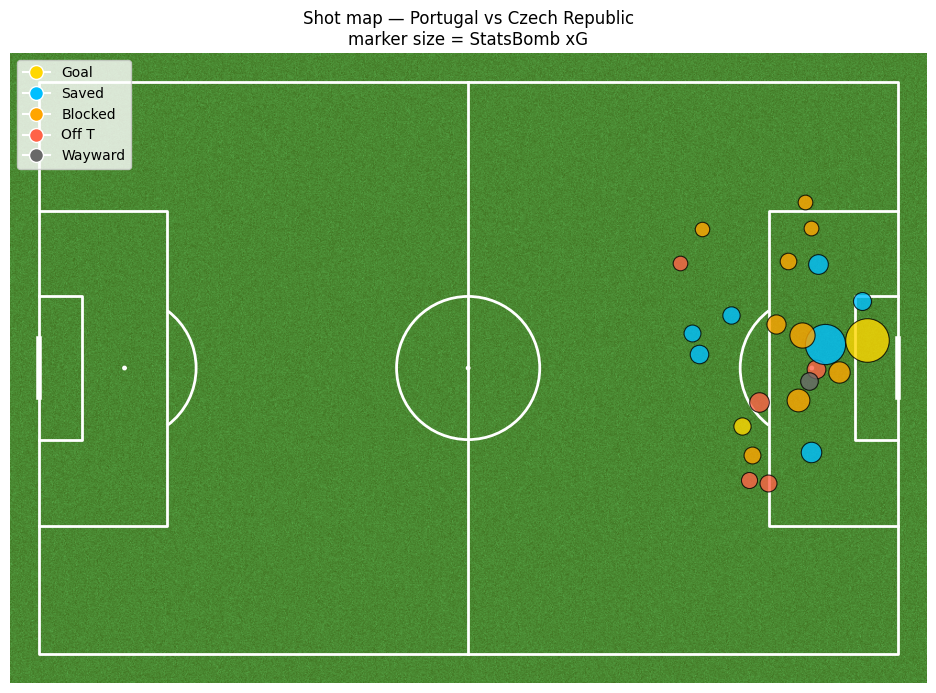

In [6]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

outcome_colors = {
    'Goal': 'gold',
    'Saved': 'deepskyblue',
    'Blocked': 'orange',
    'Off T': 'tomato',
    'Wayward': 'dimgrey',
}

for _, shot in shots.iterrows():
    x, y = shot['location']
    color = outcome_colors[shot['shot_outcome']]
    size = 100 + shot['shot_statsbomb_xg'] * 1500
    pitch.scatter(x, y, s=size, color=color, edgecolors='black', linewidth=0.8,
                  alpha=0.8, ax=ax, zorder=2)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=label)
           for label, c in outcome_colors.items()]
ax.legend(handles=handles, loc='upper left', fontsize=10)
ax.set_title(f"Shot map — {euro_matches.iloc[0]['home_team']} vs {euro_matches.iloc[0]['away_team']}\n"
             "marker size = StatsBomb xG", fontsize=12)
plt.show()

## StatsBomb — lineups

In [7]:
lineups = load_lineups(sample_match_id)
list(lineups.keys())

['Portugal', 'Czech Republic']

## SkillCorner — sample tracking match

Open data tracking for one match, loaded through `kloppy`. This is the physical layer Module B will combine with StatsBomb event data.

In [8]:
tracking = load_skillcorner_tracking(match_id=1925299)
print(type(tracking))
print(f"{len(tracking.records)} frames")
tracking.metadata.teams

<class 'kloppy.domain.models.tracking.TrackingDataset'>
47942 frames


[Team(team_id=1802, name='Brisbane Roar FC', ground=home, starting_formation=None, formations=<TimeContainer>, players=[<Player name='Ben Warland' player_id='51050'>, <Player name='Neicer Aldhair Acosta Mendez' player_id='333110'>, <Player name='Adam Zimarino' player_id='797298'>, <Player name='Keegan Jelacic' player_id='560986'>, <Player name='Jack Hingert' player_id='51722'>, <Player name='Jay O'Shea' player_id='51002'>, <Player name='Florin Bérenguer' player_id='560882'>, <Player name='Quinn MacNicol' player_id='795541'>, <Player name='Jacob  Brazete' player_id='965698'>, <Player name='Hosine Bility' player_id='69111'>, <Player name='Matt Acton' player_id='50950'>, <Player name='Louis Zabala' player_id='560898'>, <Player name='Walid Shour' player_id='287934'>, <Player name='Thomas Waddingham' player_id='795537'>, <Player name='Macklin Freke' player_id='50999'>, <Player name='Lucas Herrington' player_id='965697'>, <Player name='Antonee Alan Burke-Gilroy' player_id='560983'>, <Player 

In [9]:
tracking_df = tracking.to_df()
tracking_df.head()

,period_id,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y,ball_z,ball_speed,560985_x,560985_y,560985_d,560985_s,809166_x,809166_y,809166_d,809166_s,560989_x,560989_y,560989_d,560989_s,11897_x,11897_y,11897_d,11897_s,50982_x,50982_y,50982_d,50982_s,795530_x,...,966115_d,966115_s,560988_x,560988_y,560988_d,560988_s,51722_x,51722_y,51722_d,51722_s,795541_x,795541_y,795541_d,795541_s,965698_x,965698_y,965698_d,965698_s,809869_x,809869_y,809869_d,809869_s,333110_x,333110_y,333110_d,333110_s,966113_x,966113_y,966113_d,966113_s
0,1,0 days 00:00:00,10,dead,NaN,0.493714,0.491471,0.29,None,0.110952,0.484118,None,None,0.267143,0.485441,None,None,0.263143,0.359265,None,None,0.291429,0.633676,None,None,0.286857,0.205588,None,None,0.397619,...,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None
1,1,0 days 00:00:00.100000,11,dead,NaN,0.497810,0.495735,0.19,None,0.107429,0.483971,None,None,0.266571,0.486765,None,None,0.261714,0.358676,None,None,0.290190,0.635294,None,None,0.286190,0.203971,None,None,0.397714,...,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None
2,1,0 days 00:00:00.200000,12,dead,NaN,0.498952,0.499265,0.13,None,0.104286,0.483824,None,None,0.266095,0.488088,None,None,0.260476,0.358235,None,None,0.288952,0.636912,None,None,0.285619,0.202353,None,None,0.397905,...,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None
3,1,0 days 00:00:00.300000,13,dead,NaN,0.498667,0.501471,0.13,None,0.101333,0.483824,None,None,0.265619,0.489265,None,None,0.259429,0.357794,None,None,0.287905,0.638235,None,None,0.285048,0.201029,None,None,0.398000,...,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None
4,1,0 days 00:00:00.400000,14,dead,NaN,0.495048,0.502941,0.25,None,0.098762,0.483824,None,None,0.265333,0.490294,None,None,0.258476,0.357500,None,None,0.287048,0.639559,None,None,0.284476,0.199853,None,None,0.398190,...,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,None,None


## Takeaways

- Both data sources load cleanly through `src/data_loader.py` — no auth needed for either.
- StatsBomb events carry `shot_statsbomb_xg` already, useful as a benchmark once our own model exists (Session S3/S4).
- SkillCorner tracking gives per-frame X/Y at broadcast tracking resolution — physical metrics (speed, sprints, acceleration) will need to be derived from this in Session S5.
- Next session (S2): build `src/features.py` — distance/angle/body part/assist type/game state features, using Leverkusen 2023/24 + PL 2015/16 for training and Euro 2024 as the held-out tournament test set.